# Classification

<h3>1. Imports</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,f1_score, roc_auc_score, precision_score,recall_score,balanced_accuracy_score,classification_report,confusion_matrix , ConfusionMatrixDisplay)


<h3>2. Chargement et exploration des données</h3>

In [17]:
df = pd.read_csv('data_final_promax.csv')
print("Dimensions des données:", df.shape)
df = df.rename(columns={'est_retarde': 'delay_15min'}) 
df.head()


Dimensions des données: (781081, 14)


,depdelay,arrdelay,origin,dest,uniquecarrier,scheduledhour,tailnum,numflights,origincityname,windspeed,windgustdummy,raindummy,snowdummy,is_holiday_season
0,-2,-11.0,5.875096,5.678700,5.262673,17,4.984410,15.471000,5.875096,9.133333,1,0,0,False
1,-10,-1.0,7.817186,2.527276,8.747081,8,9.403636,20.132999,5.577255,13.000000,0,0,0,False
2,23,13.0,5.994635,3.972538,8.646316,8,10.882033,17.000999,5.994635,7.166667,1,0,0,False
3,-4,-14.0,-0.443869,3.599142,6.162031,7,6.645973,17.858999,-0.443869,21.000000,0,0,0,False
4,141,121.0,3.662890,3.787648,3.044034,21,-0.466867,20.924999,3.662890,10.833333,0,0,0,True


<h3>3. Séparation des données en train/test</h3> 

In [ ]:
X = df.drop(['delay_15min', 'arrdelay'], axis=1)
y = df['delay_15min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Proportion retards dans train: {y_train.mean():.2%}")
print(f"Proportion retards dans test: {y_test.mean():.2%}")


In [7]:
# Standarisation des features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3>4. Modélisation</h3>

Dans cette section, nous procédons à l’évaluation et à la comparaison de plusieurs modèles de classification 
(Régression Logistique, SVM, Random Forest et MLP) afin de prédire si un vol sera retardé ou non. 
Chaque algorithme est entraîné sur le jeu d’apprentissage, puis testé sur le jeu de test à l’aide de métriques standards 
(accuracy, précision, rappel, F1-score, ROC-AUC).

Afin d’améliorer les performances des modèles, nous intégrons une étape d’**optimisation des hyperparamètres** , qui consiste à rechercher automatiquement la meilleure combinaison de paramètres pour chaque algorithme. 



<h4>Entraînement des modèles</h4> 

In [59]:
# Logistic Regression
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    param_lr,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_


In [61]:
#SVM
param_svm = {
    'C': [0.01, 0.1, 1, 10]
}

grid_svm = GridSearchCV(
    LinearSVC(random_state=42, class_weight='balanced', dual=False),
    param_svm,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)
best_svm = grid_svm.best_estimator_


In [65]:
# Random Forest
param_rf = {
    'n_estimators': [100, 150],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rand_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_rf,
    n_iter=5,      
    cv=2,           
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)


rand_rf.fit(X_train_scaled, y_train)
best_rf = rand_rf.best_estimator_


Fitting 2 folds for each of 5 candidates, totalling 10 fits


In [132]:
# Neural Network
param_nn = {
    'hidden_layer_sizes': [(50,), (100,)],  
    'activation': ['relu'], 
    'alpha': [0.01],  
    'learning_rate_init': [0.01],
    'batch_size': [256] 
}

grid_nn = GridSearchCV(
    MLPClassifier(
        random_state=42,
        max_iter=200,  
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,  
        tol=1e-2,  
        verbose=False,
        solver='adam'
    ),
    param_nn,
    cv=2,  
    scoring='f1',
    n_jobs=-1,
    pre_dispatch='2*n_jobs',
    return_train_score=False
)

grid_nn.fit(X_train_scaled, y_train)
best_nn = grid_nn.best_estimator_


<h4>Évaluation des performances</h4> 

In [57]:
def evaluer_modele(model, X_test, y_test, nom_modele):
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        # Pour LinearSVC
        y_proba = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_proba)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)  
    f1_retards = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f"{nom_modele}")
    print(f"   Accuracy: {accuracy:.3f} | Balanced Accuracy: {balanced_acc:.3f}")
    print(f"   F1: {f1_retards:.3f} | ROC-AUC: {roc_auc:.3f}")
    print(f"   Precision: {precision:.3f} | Recall: {recall:.3f}")
    
    return {
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,  
        'f1_retards': f1_retards,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall
    }

In [183]:
resultats = {}

# Logistic Regression
resultats['Logistic Regression'] = evaluer_modele(best_lr, X_test_scaled, y_test, "LOGISTIC REGRESSION")

# SVM
resultats['Linear SVC'] = evaluer_modele(best_svm, X_test_scaled, y_test, "SVM")

# Random Forest
resultats['Random Forest'] = evaluer_modele(best_rf, X_test_scaled, y_test, "RANDOM FOREST")

# Neural Network
resultats['Neural Network'] = evaluer_modele(best_nn, X_test_scaled, y_test, "NEURAL NETWORK")
df_resultats = pd.DataFrame(resultats).T

LOGISTIC REGRESSION
   Accuracy: 0.890 | Balanced Accuracy: 0.868
   F1: 0.810 | ROC-AUC: 0.926
   Precision: 0.805 | Recall: 0.816
SVM
   Accuracy: 0.894 | Balanced Accuracy: 0.868
   F1: 0.815 | ROC-AUC: 0.926
   Precision: 0.824 | Recall: 0.806
RANDOM FOREST
   Accuracy: 0.902 | Balanced Accuracy: 0.861
   F1: 0.818 | ROC-AUC: 0.932
   Precision: 0.883 | Recall: 0.762
NEURAL NETWORK
   Accuracy: 0.903 | Balanced Accuracy: 0.856
   F1: 0.815 | ROC-AUC: 0.929
   Precision: 0.899 | Recall: 0.746


<h3>Comparaison des modèles</h4> 

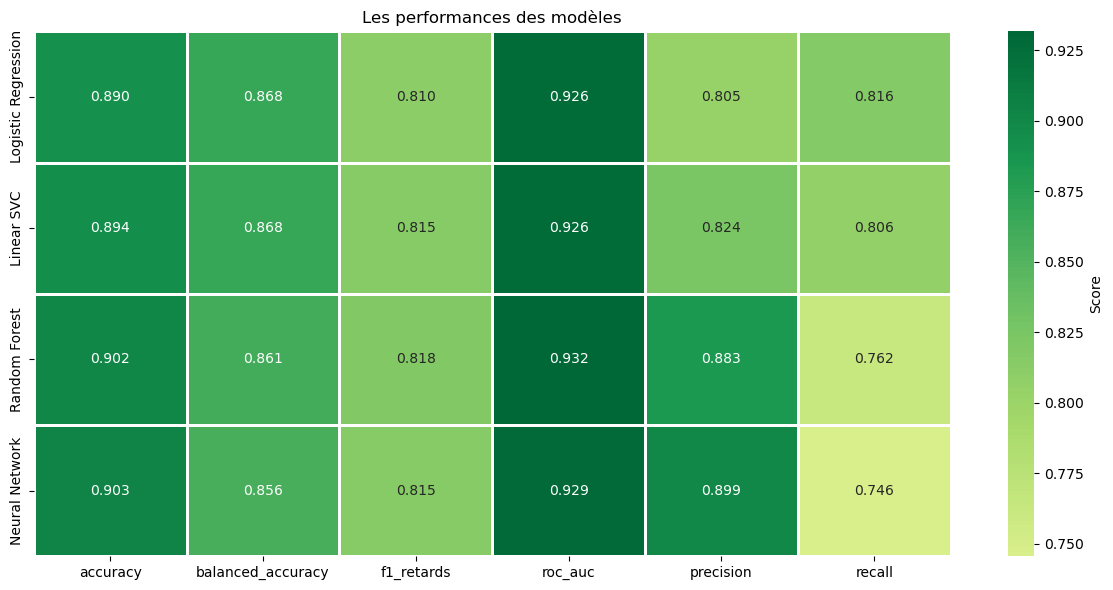

In [197]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_resultats, annot=True, cmap='RdYlGn', center=0.7, 
            fmt='.3f', linewidths=1, cbar_kws={'label': 'Score'})
plt.title('Les performances des modèles')
plt.tight_layout()
plt.show()

**Random Forest** a été sélectionné parce qu’il offre d’excellentes performances pour prédire les retards de vol. Avec un ROC-AUC de 0.932, il distingue très bien les vols retardés de ceux qui arrivent à l’heure. Sa Balanced Accuracy (0.861) et son F1-score (0.818) montrent qu’il reste fiable et équilibré entre précision et rappel. Grâce à ces résultats solides, c’est un modèle bien adapté pour une utilisation concrète dans le domaine aérien.

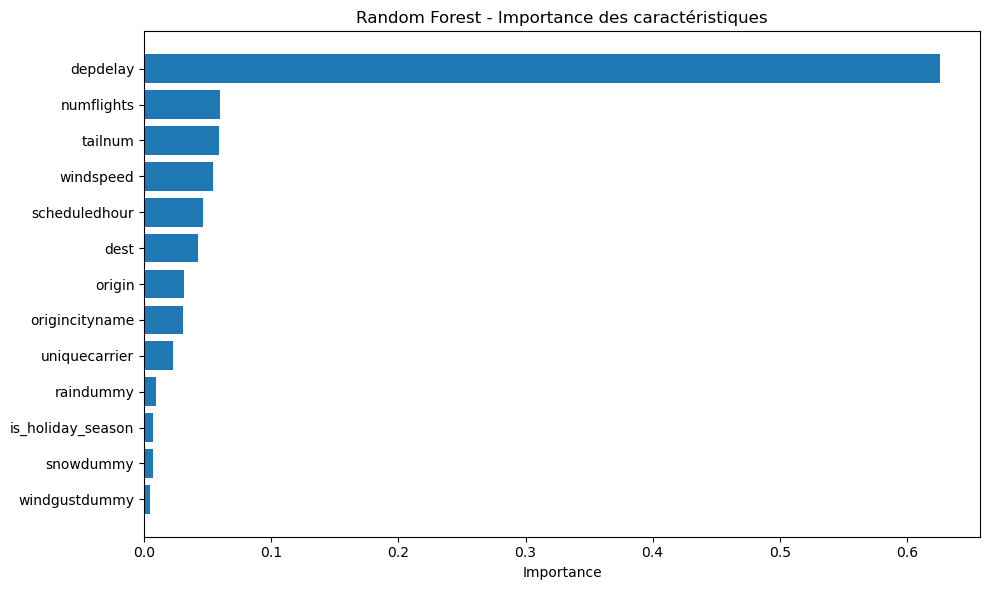

In [91]:
plt.figure(figsize=(10, 6))
importances = best_rf.feature_importances_
features = X_train.columns  

feature_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.barh(feature_imp['feature'], feature_imp['importance'])
plt.title('Random Forest - Importance des caractéristiques')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


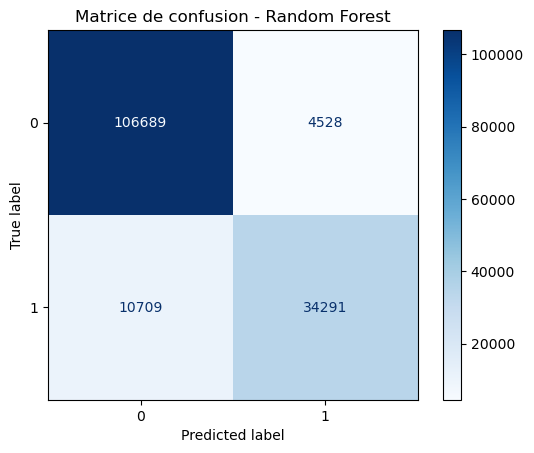

In [200]:
y_pred_rf = best_rf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matrice de confusion - Random Forest')
plt.show()
